In [263]:
%load_ext autoreload
%autoreload 2
import numpy as np
import geopandas as gpd
import pandas as pd
import os
from tile import tile_sampler

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [264]:
os.getcwd()
os.chdir(r'c:\\Users\\solan\\OneDrive\\Desktop\\IntrotoPython\\FinalProj\\cropfield-polygonization\\data')

zambia_shp = gpd.read_parquet(r'zambia_2023_attributed.parquet')

In [265]:
# test_poly = tile_sampler(zambia_shp, 'tile_id', 'area_m2', 1000, None)
test_tile = zambia_shp[zambia_shp['tile_id'] == 883180]

# Look at the bottom 25% compactness, top 25% shape index, top 25% interior edge, top 25% fractal dim
test_tile_filt = test_tile[(test_tile["compactness"] <= test_tile["compactness"].quantile(0.25)) & (test_tile["shape_index"] >= test_tile["shape_index"].quantile(0.75)) & (test_tile["interior_edge"] >= test_tile["interior_edge"].quantile(0.75)) & (test_tile["fractal_dim"] >= test_tile["fractal_dim"].quantile(0.75))]

In [293]:
test_tile_filt = test_tile_filt.to_crs(32735)
test_tile_filt.describe()

print(test_tile_filt.crs)

EPSG:32735


In [295]:
from shapely.ops import split
from shapely.geometry import Point
from shapely.ops import nearest_points
from shapely import LineString
import pandas as pd

def poly_splitter(gdf, perimeter_column, geometry_column, delta):
    """
        This function splits a polygon at the narrowest point determined using a negative buffer. 

        Arguments: 
        gdf : Geodataframe
        perimeter_column : Name of column with perimeter values
        delta: buffer step (should be positive)

        Required packages: Shapely, pandas
        
        Other relevant packages: geopandas (geodataframe creation and loading), os (directory navigation)
    """
    gdf = gdf.copy()
    gdf['sdist'] = None
    gdf['buffers_geom'] = None
    gdf['buffer_geom1'] = None
    gdf['buffer_geom2'] = None
    gdf['pinch1'] = None
    gdf['pinch2'] = None
    gdf['line'] = None
    gdf['cut_geom1'] = None
    gdf['cut_geom2'] = None

    for idx, row in gdf.iterrows():
        max_len = gdf.at[idx, perimeter_column]
        current_buff = 0
        while current_buff <= max_len:
            current_buff += delta
            buffered = row[geometry_column].buffer(-current_buff)
            if buffered.is_empty:  # fully eroded — no split possible
                break
            if buffered.geom_type == 'MultiPolygon':
                geoms = list(buffered.geoms)
                print(f"Split at row {idx}, buffer distance {current_buff:.3f}")
                gdf.at[idx, 'buffers_geom'] = buffered
                gdf.at[idx, 'sdist'] = -current_buff  # keep negative to match original
                gdf.at[idx, 'buffer_geom1'] = geoms[0]
                gdf.at[idx, 'buffer_geom2'] = geoms[1]
                break
        else:
            print(f"No split for row {idx} within max_len={max_len}")

    # Connecting narrowest part
    for idx, row in gdf.iterrows():
        if pd.isna(row['sdist']):
            continue
        else:
            p1, p2 = nearest_points(row['buffer_geom1'], row['buffer_geom2'])
            gdf.at[idx, 'pinch1'] = p1
            gdf.at[idx, 'pinch2'] = p2
            gdf.at[idx, 'line'] = LineString([p1, p2])

    # Creating Cut Line (Perpendicular Line) and cutting
    for idx, row in gdf.iterrows():
        if pd.isna(row['sdist']):
            continue
        else: 
            bounds = gdf.at[idx, geometry_column].bounds
            dist = max(bounds[2] - bounds[0], bounds[3] - bounds[1])
            point1 = gdf.at[idx, 'pinch1']
            point2 = gdf.at[idx, 'pinch2']
            dx = point1.x - point2.x
            dy = point1.y - point2.y
            midpoint = Point((point1.x + point2.x) / 2, (point1.y + point2.y) / 2)
            perp_slope = -(dx/dy)
            perp_line = LineString([(midpoint.x - dist, midpoint.y - perp_slope * dist), (midpoint.x + dist, midpoint.y + perp_slope * dist)])
            cut = split(gdf.at[idx, 'geometry'], perp_line)
            gdf.at[idx, 'cut_geom1'] = cut.geoms[0]
            gdf.at[idx, 'cut_geom2'] = cut.geoms[1]
    return gdf 

poly_splitter(test_tile_filt, 'perimeter_m', 'geometry', delta=0.1)


Split at row 8104396, buffer distance 5.200
Split at row 8104405, buffer distance 5.300
Split at row 8104443, buffer distance 4.100
Split at row 8104482, buffer distance 1.900
Split at row 8104492, buffer distance 4.800
Split at row 8104495, buffer distance 4.900
Split at row 8104549, buffer distance 2.000
Split at row 8104770, buffer distance 4.100
Split at row 8104866, buffer distance 3.100
Split at row 8104900, buffer distance 2.700
Split at row 8104917, buffer distance 0.800
Split at row 8104979, buffer distance 5.300
Split at row 8105139, buffer distance 4.400
Split at row 8105197, buffer distance 1.400
Split at row 8105360, buffer distance 2.400
Split at row 8105400, buffer distance 3.100
Split at row 8105420, buffer distance 5.100
Split at row 8105510, buffer distance 2.800
Split at row 8105535, buffer distance 1.200
Split at row 8105565, buffer distance 4.300
Split at row 8105567, buffer distance 6.300
Split at row 8105582, buffer distance 4.400
Split at row 8105654, buffer dis

area_m2   area_ha  perimeter_m  compactness  shape_index  \
8104396  1420.562034  0.142056   200.659649     0.443353     1.501845   
8104405  1401.827952  0.140183   198.337865     0.447810     1.494353   
8104443  1308.170177  0.130817   193.084053     0.440942     1.505946   
8104482   663.478992  0.066348   177.608453     0.264308     1.945114   
8104492   629.764179  0.062976   133.606113     0.443338     1.501870   
8104495   592.280326  0.059228   127.821908     0.455540     1.481620   
8104549  1795.376697  0.179538   254.424339     0.348536     1.693854   
8104770   453.565785  0.045357   118.382450     0.406701     1.568058   
8104789   183.679724  0.018368    74.979364     0.410570     1.560652   
8104866  2706.174597  0.270617   386.784388     0.227315     2.097423   
8104900   824.630375  0.082463   157.899055     0.415633     1.551118   
8104917   682.212188  0.068221   159.647284     0.336361     1.724237   
8104979  2013.052490  0.201305   278.377071     0.326436     1.750254   
8105034   217.393555  0.021739    80.647635     0.420023     1.542991   
8105097   221.160350  0.022116    78.210139     0.454351     1.483558   
8105139   982.163460  0.098216   185.946240     0.356959     1.673750   
8105197  1356.908553  0.135691   217.847558     0.359298     1.668294   
8105200   258.638491  0.025864    89.811684     0.402937     1.575365   
8105230   281.140515  0.028114    94.093806     0.399035     1.583049   
8105357   412.326541  0.041233   112.249408     0.411228     1.559403   
8105360   262.390187  0.026239    85.021719     0.456140     1.480646   
8105400  1540.695272  0.154070   225.748391     0.379907     1.622413   
8105420   993.415470  0.099342   178.472902     0.391919     1.597357   
8105433  1480.772027  0.148077   204.417159     0.445311     1.498540   
8105493   704.710945  0.070471   148.348262     0.402398     1.576420   
8105510  1945.528445  0.194553   288.523630     0.293687     1.845260   
8105535  1057.136522  0.105714   237.441003     0.235629     2.060086   
8105565  1293.344023  0.129334   206.434945     0.381380     1.619277   
8105567  1225.867305  0.122587   184.596993     0.452068     1.487298   
8105582  1439.573934  0.143957   230.591662     0.340217     1.714438   
8105654  1416.997193  0.141700   221.754763     0.362104     1.661818   
8105727   536.030256  0.053603   151.566379     0.293220     1.846730   
8105747   963.396502  0.096340   167.555653     0.431218     1.522831   
8105770   217.429634  0.021743    81.157839     0.414828     1.552624   
8105793  1921.552881  0.192155   270.643697     0.329660     1.741674   
8105801  1604.223655  0.160422   233.033157     0.371227     1.641271   
8105884   670.931102  0.067093   160.445189     0.327517     1.747362   
8105894  1836.640599  0.183664   298.175488     0.259591     1.962704   
8105915   404.837605  0.040484   110.073065     0.419883     1.543248   
8105941  1004.507003  0.100451   170.887935     0.432255     1.521003   
8106014   258.649063  0.025865    85.465522     0.444978     1.499100   

         interior_edge  fractal_dim   tile_id  polygon_index    polygon_id  \
8104396       0.141254     1.460739  883180.0            9.0  8.831800e+11   
8104405       0.141485     1.460202  883180.0           18.0  8.831800e+11   
8104443       0.147599     1.466790  883180.0           56.0  8.831800e+11   
8104482       0.267693     1.594331  883180.0           95.0  8.831800e+11   
8104492       0.212153     1.518893  883180.0          105.0  8.831800e+11   
8104495       0.215813     1.519628  883180.0          108.0  8.831800e+11   
8104549       0.141711     1.478453  883180.0          162.0  8.831800e+11   
8104770       0.261004     1.560834  883180.0          383.0  8.831800e+11   
8104789       0.408207     1.656264  883180.0          402.0  8.831800e+11   
8104866       0.142927     1.507693  883180.0          479.0  8.831800e+11   
8104900       0.191479     1.507671  883180.0          513.0  8.831800e+11   
8104917   

<Axes: >

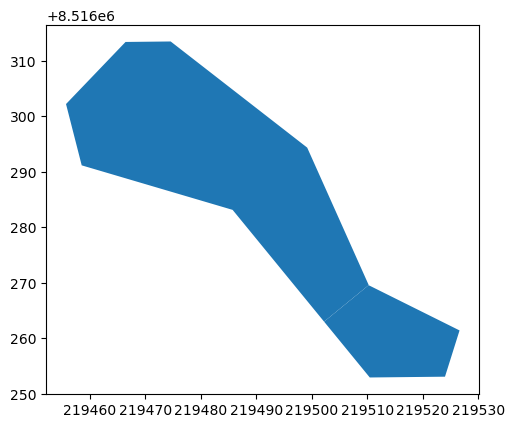

In [299]:
import geopandas as gpd

fig, ax = plt.subplots()
gpd.GeoSeries(test_tile_filt['cut_geom1'].head(1).dropna()).plot(ax = ax)
gpd.GeoSeries(test_tile_filt['cut_geom2'].head(1).dropna()).plot(ax = ax)

In [ ]:
from shapely.geometry import Point

# Test poly (1)
point = Point(24.4135987, -13.3993874)  

# Select the polygon that contains the point
test_poly = test_tile[test_tile.geometry.contains(point)]
test_poly = test_poly.to_crs(32735)

test_poly.info()

test_poly.plot()

In [ ]:
test_poly.geometry.bounds

pd.set_option('display.max_colwidth', None)

geom = test_poly['geometry'].iloc[0]

coords = list(geom.exterior.coords)


x, y = zip(*coords)

minx, maxx = min(x), max(x)
miny, maxy = min(y), max(y)
print(minx, maxx)
print(miny, maxy)
print(test_poly.geometry.bounds)
print(coords)

In [ ]:
# TEST
# zam_filt['min_len'] = zam_filt.geometry.apply(
#     lambda g: -(min(g.bounds[2] - g.bounds[0], g.bounds[3] - g.bounds[1]) / 2)
# )

import matplotlib.pyplot as plt 
import matplotlib.cm as cm 

fig, ax = plt.subplots()

delta = .5 # buffer step
max_len = 1000000

idx = test_poly.index[0]

buffers = []
current_buff = 0

while current_buff <= max_len:
    current_buff += delta
    buffered = test_poly['geometry'].iloc[0].buffer(-current_buff)
    buffers.append(buffered)
    if buffered.geom_type == 'MultiPolygon':
        geoms = list(buffered.geoms)
        print(f"Split happened at buffer distance {current_buff}.")
        test_poly.loc[idx, 'geometry_test'] = buffered # buffer geometry
        test_poly.loc[idx, 'sdist'] = -current_buff #buffer 
        test_poly.loc[idx, 'buffer_geom1'] = geoms[0] # geometry 1 for split poly
        test_poly.loc[idx, 'buffer_geom2'] = geoms[1] # geometry 2 for split poly
        break
else:
    print(f"No split within dimension limit")


for geom, color in zip(buffers, colors): 
    gpd.GeoSeries([geom]).plot(ax = ax, facecolor = 'none', edgecolor = 'blue', linewidth = 0.5)

test_poly.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Original')
plt.title(f"Buffer progression — split at {current_buff:.2f}")
plt.show()

In [ ]:
fig, ax = plt.subplots()
gpd.GeoSeries(test_poly['buffer_geom1']).plot(ax=ax, edgecolor='red', facecolor='none')
gpd.GeoSeries(test_poly['buffer_geom2']).plot(ax=ax, edgecolor='blue', facecolor='none')
plt.show()

In [ ]:
# NEAREST POINTS TEST

from shapely.ops import nearest_points
from shapely import ops 
from shapely import LineString


p1, p2 = nearest_points(test_poly['buffer_geom1'].iloc[0], test_poly['buffer_geom2'].iloc[0])
test_poly.at[idx, 'pinch1'] = p1
test_poly.at[idx, 'pinch2'] = p2
test_poly.at[idx, 'line'] = LineString([p1, p2]) # line connecting closest points

# Goal is to create perpendicular line? 

fig, ax = plt.subplots()
test_poly.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Original')
gpd.GeoSeries(test_poly['buffer_geom1']).plot(ax=ax, edgecolor='red', facecolor='none')
gpd.GeoSeries(test_poly['buffer_geom2']).plot(ax=ax, edgecolor='blue', facecolor='none')
gpd.GeoSeries(test_poly['line']).plot(ax = ax, edgecolor = 'black')
plt.show()
# line_buff = test_poly['line'].buffer(abs(row['sdist']))
# zam_filt.at[idx, 'line_buff'] = line_buff

In [ ]:
test_poly['geometry'].length

In [ ]:
dist

In [ ]:
# Finding perpendicular line to connecting line
line = gpd.GeoDataFrame(geometry = test_poly['line']) # original polygon line

dist = (test_poly['geometry'].length)*.01

point1 = test_poly['pinch1'].iloc[0]
point2 = test_poly['pinch2'].iloc[0]

dx = point1.x - point2.x
dy = point1.y - point2.y
 
midpoint = Point(
    (point1.x + point2.x) / 2,
    (point1.y + point2.y) / 2
)

perp_slope = -(dx/dy)

perp_line = LineString([(midpoint.x - dist, midpoint.y - perp_slope * dist), (midpoint.x + dist, midpoint.y + perp_slope * dist)])

In [ ]:
fig, ax = plt.subplots()
gpd.GeoSeries(test_poly['line']).plot(ax = ax, edgecolor = 'black')
gpd.GeoSeries(perp_line).plot(ax=ax, color = 'red')
gpd.GeoSeries([midpoint]).plot(ax=ax, color = 'green', markersize = 10)
plt.show()

In [ ]:
fig, ax = plt.subplots()
test_poly.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Original')
gpd.GeoSeries(test_poly['buffer_geom1']).plot(ax=ax, edgecolor='red', facecolor='none')
gpd.GeoSeries(test_poly['buffer_geom2']).plot(ax=ax, edgecolor='blue', facecolor='none')
gpd.GeoSeries(test_poly['line']).plot(ax = ax, edgecolor = 'black')
gpd.GeoSeries(perp_line).plot(ax=ax, color = 'purple')
plt.show()

In [ ]:
test_poly

In [ ]:
gpd.GeoSeries(perp_line)
from shapely.ops import split

cut = split(test_poly['geometry'].iloc[0], perp_line)

test_poly['cut_geom1'] = cut.geoms[0]
test_poly['cut_geom2'] = cut.geoms[1]

fig, ax = plt.subplots()
gpd.GeoSeries(test_poly['cut_geom1']).plot(ax = ax)
gpd.GeoSeries(test_poly['cut_geom2']).plot(ax = ax)

Now trying with test_tile

In [276]:
# test_poly = tile_sampler(zambia_shp, 'tile_id', 'area_m2', 1000, None)

test_tile = zambia_shp[zambia_shp['tile_id'] == 883180]
test_tile = test_tile.to_crs(32735)
display(test_tile['geometry'].length)
test_tile.info()

8104387     148.587853
8104388     189.251256
8104389      70.792060
8104390     495.797101
8104391     291.376526
              ...     
8106361    1109.494730
8106362    1028.369596
8106363     363.904232
8106364     119.845620
8106365     194.675938
Length: 1979, dtype: float64

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1979 entries, 8104387 to 8106365
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   area_m2        1979 non-null   float64 
 1   area_ha        1979 non-null   float64 
 2   perimeter_m    1979 non-null   float64 
 3   compactness    1979 non-null   float64 
 4   shape_index    1979 non-null   float64 
 5   interior_edge  1979 non-null   float64 
 6   fractal_dim    1979 non-null   float64 
 7   tile_id        1979 non-null   float64 
 8   polygon_index  1979 non-null   float64 
 9   polygon_id     1979 non-null   float64 
 10  geometry       1979 non-null   geometry
dtypes: float64(10), geometry(1)
memory usage: 185.5 KB


In [277]:
tile_filt = test_tile[(test_tile["compactness"] <= test_tile["compactness"].quantile(0.25)) & (test_tile["shape_index"] >= test_tile["shape_index"].quantile(0.75)) & (test_tile["interior_edge"] >= test_tile["interior_edge"].quantile(0.75)) & (test_tile["fractal_dim"] >= test_tile["fractal_dim"].quantile(0.75))]
tile_filt.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 41 entries, 8104396 to 8106014
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   area_m2        41 non-null     float64 
 1   area_ha        41 non-null     float64 
 2   perimeter_m    41 non-null     float64 
 3   compactness    41 non-null     float64 
 4   shape_index    41 non-null     float64 
 5   interior_edge  41 non-null     float64 
 6   fractal_dim    41 non-null     float64 
 7   tile_id        41 non-null     float64 
 8   polygon_index  41 non-null     float64 
 9   polygon_id     41 non-null     float64 
 10  geometry       41 non-null     geometry
dtypes: float64(10), geometry(1)
memory usage: 3.8 KB


<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 41 entries, 8104396 to 8106014
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   area_m2        41 non-null     float64 
 1   area_ha        41 non-null     float64 
 2   perimeter_m    41 non-null     float64 
 3   compactness    41 non-null     float64 
 4   shape_index    41 non-null     float64 
 5   interior_edge  41 non-null     float64 
 6   fractal_dim    41 non-null     float64 
 7   tile_id        41 non-null     float64 
 8   polygon_index  41 non-null     float64 
 9   polygon_id     41 non-null     float64 
 10  geometry       41 non-null     geometry
dtypes: float64(10), geometry(1)
memory usage: 3.8 KB
Split happened for row 8104396 at buffer distance -5.1999999999999975.
Split happened for row 8104405 at buffer distance -5.299999999999997.
Split happened for row 8104443 at buffer distance -4.100000000000001.
Split happened for row 8104482 at

c:\Users\solan\anaconda3\envs\arcgispro-gpd\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\solan\anaconda3\envs\arcgispro-gpd\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\solan\anaconda3\envs\arcgispro-gpd\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

No split for row 8105493 within dimension limit
Split happened for row 8105510 at buffer distance -2.800000000000001.
Split happened for row 8105535 at buffer distance -1.2.
Split happened for row 8105565 at buffer distance -4.300000000000001.
Split happened for row 8105567 at buffer distance -6.299999999999994.
Split happened for row 8105582 at buffer distance -4.4.
Split happened for row 8105654 at buffer distance -6.299999999999994.
Split happened for row 8105727 at buffer distance -1.4000000000000001.
Split happened for row 8105747 at buffer distance -3.700000000000002.
Split happened for row 8105770 at buffer distance -2.2000000000000006.
Split happened for row 8105793 at buffer distance -5.599999999999996.
Split happened for row 8105801 at buffer distance -3.1000000000000014.
Split happened for row 8105884 at buffer distance -0.6.
Split happened for row 8105894 at buffer distance -2.2000000000000006.
Split happened for row 8105915 at buffer distance -2.2000000000000006.
No split 

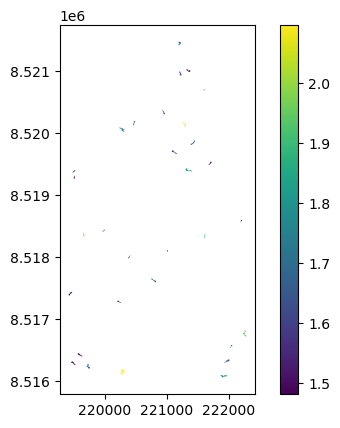

In [280]:
tile_filt = test_tile[(test_tile["compactness"] <= test_tile["compactness"].quantile(0.25)) & (test_tile["shape_index"] >= test_tile["shape_index"].quantile(0.75)) & (test_tile["interior_edge"] >= test_tile["interior_edge"].quantile(0.75)) & (test_tile["fractal_dim"] >= test_tile["fractal_dim"].quantile(0.75))]
tile_filt.info()

delta = .1 # buffer step
# max_len = max(tile_filt['perimeter_m'])
max_len = tile_filt.at[idx, 'perimeter_m']

for idx, row in tile_filt.iterrows(): 
    current_buff = 0
    while current_buff <= max_len: # update len per row?
        current_buff += delta
        buffered = row['geometry'].buffer(-current_buff)
        if buffered.geom_type == 'MultiPolygon':
            geoms = list(buffered.geoms) # extracting buffers
            print(f"Split happened for row {idx} at buffer distance {-current_buff}.")
            tile_filt.at[idx, 'buffers_geom'] = buffered # overall buffer geom
            tile_filt.at[idx, 'sdist'] = current_buff # buffer distance from perimeter
            tile_filt.at[idx, 'buffer_geom1'] = geoms[0] # geom 1 for split poly
            tile_filt.at[idx, 'buffer_geom2'] = geoms[1] # geom 2 for split poly
            break  
    else:
        print(f"No split for row {idx} within dimension limit")

tile_filt.dropna(subset = ['sdist']).plot(column="shape_index", cmap="viridis", legend=True)
plt.show()


In [ ]:
# Connecting narrowest part
for idx, row in test_tile.iterrows():
    if pd.isna(row['sdist']):
        continue
    else:
        p1, p2 = nearest_points(row['buffer_geom1'], row['buffer_geom2'])
        test_tile.at[idx, 'pinch1'] = p1
        test_tile.at[idx, 'pinch2'] = p2
        test_tile.at[idx, 'line'] = LineString([p1, p2])

# Creating Cut Line (Perpendicular Line) and cutting
cut_geoms = []
for idx, row in test_tile.iterrows():
    if pd.isna(row['sdist']):
        continue
    else: 
        bounds = test_tile.at[idx, 'geometry'].bounds
        dist = max(bounds[2] - bounds[0], bounds[3] - bounds[1])
        point1 = test_tile.at[idx, 'pinch1']
        point2 = test_tile.at[idx, 'pinch2']
        dx = point1.x - point2.x
        dy = point1.y - point2.y
        midpoint = Point((point1.x + point2.x) / 2, (point1.y + point2.y) / 2)
        perp_slope = -(dx/dy)
        perp_line = LineString([(midpoint.x - dist, midpoint.y - perp_slope * dist), (midpoint.x + dist, midpoint.y + perp_slope * dist)])
        cut = split(test_tile.at[idx, 'geometry'], perp_line)
        test_tile.at[idx, 'cut_geom1'] = cut.geoms[0]
        test_tile.at[idx, 'cut_geom2'] = cut.geoms[1]

fig, ax = plt.subplots()
gpd.GeoSeries(test_tile.dropna(subset=['cut_geom1'])['cut_geom1']).plot(ax=ax, facecolor='none', edgecolor='red')
gpd.GeoSeries(test_tile.dropna(subset=['cut_geom2'])['cut_geom2']).plot(ax=ax, facecolor='none', edgecolor='blue')
plt.show()


In [ ]:
fig, ax = plt.subplots()
gpd.GeoSeries(test_tile.dropna(subset=['cut_geom1'])['cut_geom1']).head(20).plot(ax=ax, facecolor='none', edgecolor='red')
gpd.GeoSeries(test_tile.dropna(subset=['cut_geom2'])['cut_geom2']).head(20).plot(ax=ax, facecolor='none', edgecolor='blue')
plt.show()

In [ ]:
display(zam_filt['geometry'].length)
zam_filt.info()

In [ ]:
# geopandas buffer function
zam_filt['geometry_test'] = zam_filt['geometry'].buffer(-2)

zam_filt

In [ ]:
zam_filt[]

In [ ]:
selected.geometry.bounds

In [ ]:
selected.geometry.bounds

selected['min_len'] = min((selected.geometry.bounds['maxx']-selected.geometry.bounds['minx']).values[0], (selected.geometry.bounds['maxy']-selected.geometry.bounds['miny']).values[0])/2

selected['min_len']

In [ ]:
selected['geometry'].bounds['minx']
selected.geometry.bounds['maxx']-selected.geometry.bounds['minx']

In [ ]:
# finding shorter dimension of every polygon and halving it (approximation for max buffer distance)
zam_filt['min_len'] = zam_filt.geometry.apply(
    lambda g: -(min(g.bounds[2] - g.bounds[0], g.bounds[3] - g.bounds[1]) / 2)
)

delta = -.5 # buffer step


for idx, row in zam_filt.iterrows():
    current_buff = 0
    while current_buff >= row['min_len']: 
        current_buff += delta
        buffered = row['geometry'].buffer(current_buff)
        if buffered.geom_type == 'MultiPolygon':
            geoms = list(buffered.geoms) # extracting buffers
            print(f"Split happened for row {idx} at buffer distance {current_buff}.")
            zam_filt.at[idx, 'geometry_test'] = buffered
            zam_filt.at[idx, 'sdist'] = current_buff
            zam_filt.at[idx, 'buffer_geom1'] = geoms[0]
            zam_filt.at[idx, 'buffer_geom2'] = geoms[1]
            break  
    else:
        print(f"No split for row {idx} within dimension limit")
 

In [ ]:
zam_filt

## open in arc and  check the width 

In [ ]:
   ## find where the two separate polygons are closest, this is where
    ## the internal buffering pinched off into two polygons.



from shapely.ops import nearest_points
from shapely.ops import split
from shapely import LineString

for idx, row in zam_filt.iterrows():
    if pd.isna(row['sdist']):
        continue
    else:
        p1, p2 = nearest_points(row['buffer_geom1'], row['buffer_geom2'])
        zam_filt.at[idx, 'pinch1'] = p1
        zam_filt.at[idx, 'pinch2'] = p2
        zam_filt.at[idx, 'line'] = LineString([p1, p2])
        line_buff = row['line'].buffer(abs(row['sdist']))
        zam_filt.at[idx, 'line_buff'] = line_buff

        

In [ ]:

from shapely.ops import Point
from shapely.ops import snap

## use min_len * 10? maybe to incresae line ? 
## after identifying multi part polygon, reverse buffer ? 
## ideally it should perfectly touch at middle point and use as a mask to clip 
## distance buffer distance too? 

## work on multi neck problem later 

## Scaling function up ? corner cases (long, multiple necks, wide neck, etc etc)

for idx, row in zam_filt.iterrows():
    if pd.isna(row['sdist']):
        continue
    else:
        dx = row['pinch2'].x - row['pinch1'].x
        dy = row['pinch2'].y - row['pinch1'].y
        length = sqrt(dx**2 + dy**2)
        dx, dy = dx/length * abs(row['sdist'])*20, dy/length * abs(row['sdist'])*20 # normalize to unit vector for x and y directions, multiple by sdist * 2 
        new_p1 = Point(row['pinch1'].x - dx, row['pinch1'].y - dy)
        new_p2 = Point(row['pinch2'].x + dx, row['pinch2'].y + dy)
        new_line = LineString([new_p1, new_p2])
        new_line = snap(new_line, row['geometry'], tolerance=1e-6)
        cut = split(row['geometry'], new_line)
        parts = list(cut.geoms)
        print(f"Row {idx}: {len(parts)} parts")
    
    if len(parts) < 2:
        gpd.GeoDataFrame(geometry=[row['geometry'], new_line]).plot(color=['blue','red'])
        continue
    
    zam_filt.at[idx, 'split_geom1'] = parts[0]
    zam_filt.at[idx, 'split_geom2'] = parts[1]
        parts = list(cut.geoms)
        zam_filt.at[idx, 'split_geom1'] = parts[0]
        zam_filt.at[idx, 'split_geom2'] = parts[1]


In [ ]:
zam_filt
    

In [ ]:
zam_filt

In [ ]:
zam_filt.iloc[[2]].plot(column="shape_index", cmap="viridis", legend=True)